In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('n_movies.csv')
df.head()

,title,year,certificate,duration,genre,rating,description,stars,votes
0,Cobra Kai,(2018– ),TV-14,30 min,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...","177,031"
1,The Crown,(2016– ),TV-MA,58 min,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...","199,885"
2,Better Call Saul,(2015–2022),TV-MA,46 min,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...","501,384"
3,Devil in Ohio,(2022),TV-MA,356 min,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"['Emily Deschanel, ', 'Sam Jaeger, ', 'Gerardo...","9,773"
4,Cyberpunk: Edgerunners,(2022– ),TV-MA,24 min,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"['Zach Aguilar, ', 'Kenichiro Ohashi, ', 'Emi ...","15,413"


### Data Understanding

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9957 entries, 0 to 9956
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        9957 non-null   object 
 1   year         9430 non-null   object 
 2   certificate  6504 non-null   object 
 3   duration     7921 non-null   object 
 4   genre        9884 non-null   object 
 5   rating       8784 non-null   float64
 6   description  9957 non-null   object 
 7   stars        9957 non-null   object 
 8   votes        8784 non-null   object 
dtypes: float64(1), object(8)
memory usage: 700.2+ KB


title             0
year            527
certificate    3453
duration       2036
genre            73
rating         1173
description       0
stars             0
votes          1173
dtype: int64

2. Handle Missing Values

In [4]:
# Certificate 
df['certificate'] = df['certificate'].fillna('Unknown')

# Genre 
df['genre'] = df['genre'].fillna('Unknown')

# Duration 
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

# Rating 
df['rating'] = df['rating'].fillna(df['rating'].mean())

# Votes 
df['votes'] = df['votes'].str.replace(',', '')
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')
df['votes'] = df['votes'].fillna(df['votes'].median())

# Year 
df = df.dropna(subset=['year'])

3. Correct Data Types

In [5]:
# Year
df['year'] = df['year'].str.extract('(\d{4})')
df['year'] = pd.to_numeric(df['year'], errors='coerce')
# Duration
df['duration'] = df['duration'].str.replace(' min', '')
df['duration'] = pd.to_numeric(df['duration'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9430 entries, 0 to 9956
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   title        9430 non-null   object 
 1   year         9326 non-null   float64
 2   certificate  9430 non-null   object 
 3   duration     9430 non-null   int64  
 4   genre        9430 non-null   object 
 5   rating       9430 non-null   float64
 6   description  9430 non-null   object 
 7   stars        9430 non-null   object 
 8   votes        9430 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 736.7+ KB


4. Feature Engineering + Filtering

In [6]:
# Creating New Columns

# Rating Category
def rating_category(x):
    if x >= 8:
        return 'Excellent'
    elif x >= 6:
        return 'Good'
    else:
        return 'Average'

df['rating_category'] = df['rating'].apply(rating_category)

# Extracting Main Genre
df['main_genre'] = df['genre'].str.split(',').str[0]

# Popularity Score (advanced feature)
df['popularity'] = df['rating'] * df['votes']

In [7]:
# Applying Filters

# Movies after 2000
df = df[df['year'] >= 2000]

# Removing very low vote movies
df = df[df['votes'] > 1000]

In [8]:
# Final Clean Check

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 5029 entries, 0 to 9956
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            5029 non-null   object 
 1   year             5029 non-null   float64
 2   certificate      5029 non-null   object 
 3   duration         5029 non-null   int64  
 4   genre            5029 non-null   object 
 5   rating           5029 non-null   float64
 6   description      5029 non-null   object 
 7   stars            5029 non-null   object 
 8   votes            5029 non-null   float64
 9   rating_category  5029 non-null   object 
 10  main_genre       5029 non-null   object 
 11  popularity       5029 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 510.8+ KB


,title,year,certificate,duration,genre,rating,description,stars,votes,rating_category,main_genre,popularity
0,Cobra Kai,2018.0,TV-14,30,"Action, Comedy, Drama",8.5,Decades after their 1984 All Valley Karate Tou...,"['Ralph Macchio, ', 'William Zabka, ', 'Courtn...",177031.0,Excellent,Action,1504763.5
1,The Crown,2016.0,TV-MA,58,"Biography, Drama, History",8.7,Follows the political rivalries and romance of...,"['Claire Foy, ', 'Olivia Colman, ', 'Imelda St...",199885.0,Excellent,Biography,1738999.5
2,Better Call Saul,2015.0,TV-MA,46,"Crime, Drama",8.9,The trials and tribulations of criminal lawyer...,"['Bob Odenkirk, ', 'Rhea Seehorn, ', 'Jonathan...",501384.0,Excellent,Crime,4462317.6
3,Devil in Ohio,2022.0,TV-MA,356,"Drama, Horror, Mystery",5.9,When a psychiatrist shelters a mysterious cult...,"['Emily Deschanel, ', 'Sam Jaeger, ', 'Gerardo...",9773.0,Average,Drama,57660.7
4,Cyberpunk: Edgerunners,2022.0,TV-MA,24,"Animation, Action, Adventure",8.6,A Street Kid trying to survive in a technology...,"['Zach Aguilar, ', 'Kenichiro Ohashi, ', 'Emi ...",15413.0,Excellent,Animation,132551.8


## Data Visualisation


In [13]:
# ── Global Styling ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

### Plot 1 – Bar Chart: Top 10 Genres by Number of Titles

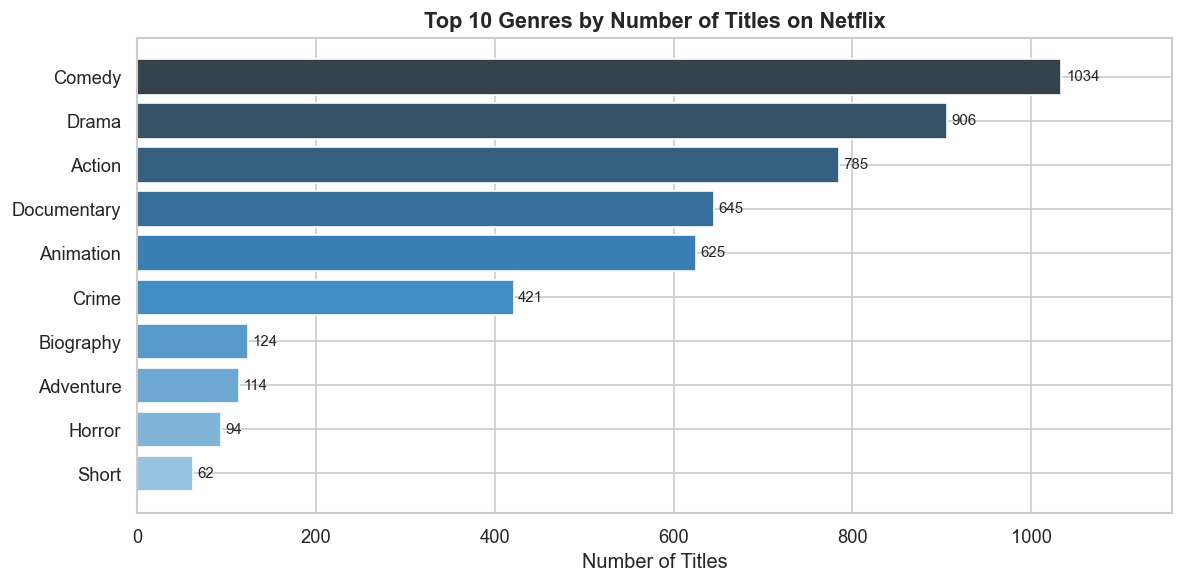

In [15]:
genre_counts = (
    df['main_genre']
    .value_counts()
    .head(10)
    .reset_index()
)
genre_counts.columns = ['Genre', 'Count']

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('Blues_d', 10)
ax.barh(genre_counts['Genre'][::-1], genre_counts['Count'][::-1], color=colors)

for i, (count, _) in enumerate(zip(genre_counts['Count'][::-1], genre_counts['Genre'][::-1])):
    ax.text(count + 5, i, str(count), va='center', fontsize=9)

ax.set_xlabel('Number of Titles')
ax.set_title('Top 10 Genres by Number of Titles on Netflix', fontsize=13, fontweight='bold')
ax.set_xlim(0, genre_counts['Count'].max() * 1.12)
plt.tight_layout()
plt.savefig('plot1_bar_genres.png', bbox_inches='tight')
plt.show()

### Plot 2 – Pie Chart: Rating Category Distribution

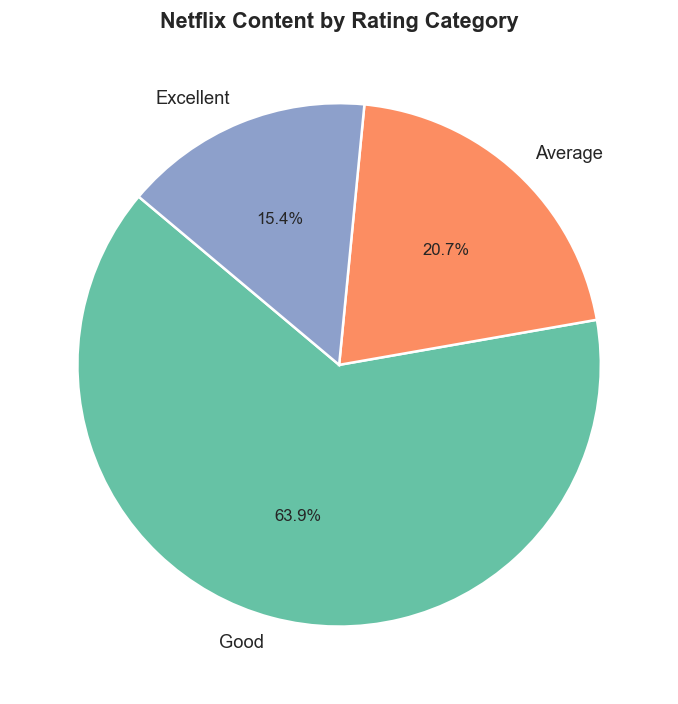

In [16]:
cat_counts = df['rating_category'].value_counts()

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(cat_counts)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(10)

ax.set_title('Netflix Content by Rating Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_pie_rating_category.png', bbox_inches='tight')
plt.show()

### Plot 3 – Histogram: Distribution of IMDb Ratings

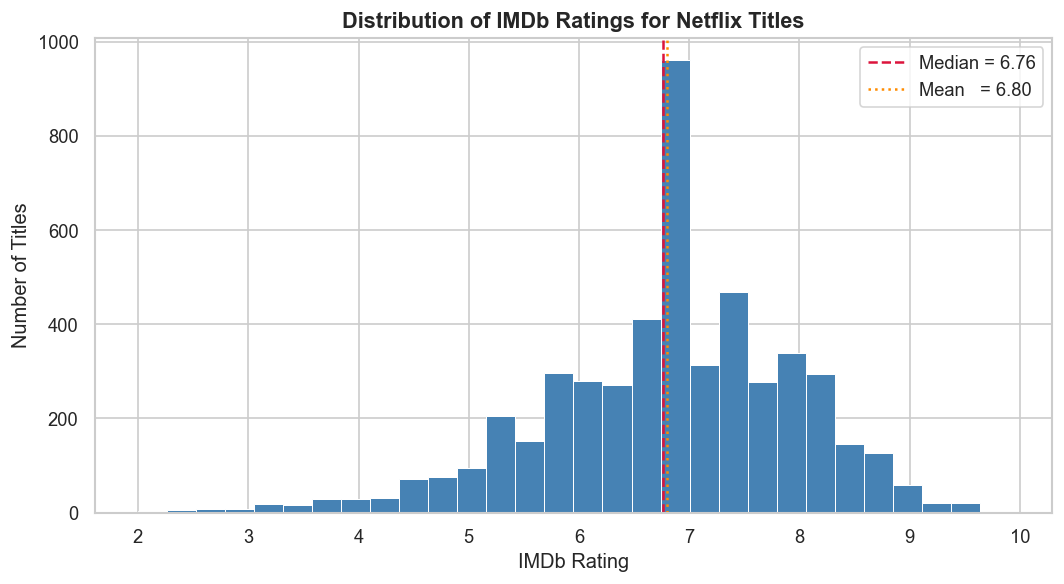

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    df['rating'],
    bins=30,
    color='steelblue',
    edgecolor='white',
    linewidth=0.6
)
median_r = df['rating'].median()
mean_r   = df['rating'].mean()
ax.axvline(median_r, color='crimson',   linestyle='--', linewidth=1.5, label=f'Median = {median_r:.2f}')
ax.axvline(mean_r,   color='darkorange', linestyle=':',  linewidth=1.5, label=f'Mean   = {mean_r:.2f}')
ax.set_xlabel('IMDb Rating')
ax.set_ylabel('Number of Titles')
ax.set_title('Distribution of IMDb Ratings for Netflix Titles', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot3_hist_ratings.png', bbox_inches='tight')
plt.show()